In [18]:
# Installation automatique des dépendances requises dans le noyau Jupyter actuel
# %pip install -r ../requirements.txt

# 🧠 Jalon 2 : Modélisation Prédictive & Apprentissage (Squelette Étudiant)


Dans ce notebook, l’objectif est de construire un pipeline de modélisation supervisée pour prédire le nombre de nouveaux cas quotidiens de Mpox (`daily_new_cases`) à partir des données historiques disponibles.

Le problème est traité comme une tâche de régression, car la variable cible est numérique. La modélisation est réalisée sur un seul pays afin d’éviter de mélanger des dynamiques épidémiques différentes entre plusieurs zones géographiques.

### 1. Préparation de l'environnement

In [19]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

sys.path.append(os.path.abspath('..'))

from src import data_clean as dc
from src import utils_viz as uv

uv.set_custom_style()

print("Librairies de modélisation prêtes.")

🎨 Charte graphique 'light' initialisée avec succès.
Librairies de modélisation prêtes.


In [47]:
df = pd.read_csv('../data/processed/owid-monkeypox-data_clean.csv')
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(by=['country', 'date']).reset_index(drop=True)

# Choix du pays à modéliser
# Ici on prend le pays avec le plus de nouveaux cas sur toute la période
selected_country = (
    df.groupby("country")["daily_new_cases"]
    .sum()
    .sort_values(ascending=False)
    .index[0]
)

print("Pays sélectionné :", selected_country)

df_country = df[df["country"] == selected_country].copy()
df_country = df_country.sort_values("date").reset_index(drop=True)

df_country.head()

Pays sélectionné : United States


,country,date,total_cases,total_deaths,daily_new_cases,daily_new_deaths
0,United States,2022-06-03,19.0,0.0,19.0,0.0
1,United States,2022-06-04,21.0,0.0,2.0,0.0
2,United States,2022-06-05,25.0,0.0,4.0,0.0
3,United States,2022-06-06,25.0,0.0,0.0,0.0
4,United States,2022-06-07,25.0,0.0,0.0,0.0


### 2. Feature engineering

La variable cible choisie est `daily_new_cases`, c’est-à-dire le nombre de nouveaux cas quotidiens de Mpox. Ce choix est plus pertinent qu’une prédiction des cas cumulés, car les cas cumulés augmentent mécaniquement avec le temps.

Afin de respecter la causalité temporelle, seules des informations disponibles avant la date à prédire sont utilisées. Des variables de retard ont donc été créées : nouveaux cas des jours précédents, nouveaux décès retardés, cas cumulés retardés, moyennes mobiles et maximums mobiles.


In [40]:
df_feat = df_country.copy()

# Variables temporelles
df_feat["year"] = df_feat["date"].dt.year
df_feat["month"] = df_feat["date"].dt.month
df_feat["dayofweek"] = df_feat["date"].dt.dayofweek

# Lags courts et longs
for lag in [1, 2, 3, 7, 14, 21]:
    df_feat[f"daily_new_cases_lag{lag}"] = df_feat["daily_new_cases"].shift(lag)

# Lags décès
df_feat["daily_new_deaths_lag1"] = df_feat["daily_new_deaths"].shift(1)
df_feat["daily_new_deaths_lag7"] = df_feat["daily_new_deaths"].shift(7)

# Variables cumulées retardées
df_feat["total_cases_lag1"] = df_feat["total_cases"].shift(1)
df_feat["total_deaths_lag1"] = df_feat["total_deaths"].shift(1)

# Moyennes mobiles basées uniquement sur le passé
for window in [3, 7, 14, 21]:
    df_feat[f"rolling_mean_{window}"] = (
        df_feat["daily_new_cases"]
        .shift(1)
        .rolling(window=window, min_periods=1)
        .mean()
    )

    df_feat[f"rolling_max_{window}"] = (
        df_feat["daily_new_cases"]
        .shift(1)
        .rolling(window=window, min_periods=1)
        .max()
    )

# Variation récente
df_feat["diff_lag1_lag7"] = (
    df_feat["daily_new_cases_lag1"] - df_feat["daily_new_cases_lag7"]
)

df_feat["diff_lag7_lag14"] = (
    df_feat["daily_new_cases_lag7"] - df_feat["daily_new_cases_lag14"]
)

# Suppression des NaN générés par les lags
df_feat = df_feat.dropna().reset_index(drop=True)

df_feat.head()

,country,date,total_cases,total_deaths,daily_new_cases,daily_new_deaths,year,month,dayofweek,daily_new_cases_lag1,...,rolling_mean_3,rolling_max_3,rolling_mean_7,rolling_max_7,rolling_mean_14,rolling_max_14,rolling_mean_21,rolling_max_21,diff_lag1_lag7,diff_lag7_lag14
0,United States,2022-06-24,173.0,0.0,31.0,0.0,2022,6,4,29.0,...,9.666667,29.0,10.000000,29.0,7.500000,29.0,6.761905,29.0,17.0,9.0
1,United States,2022-06-25,175.0,0.0,2.0,0.0,2022,6,5,31.0,...,20.000000,31.0,12.714286,31.0,9.500000,31.0,7.333333,31.0,15.0,7.0
2,United States,2022-06-26,199.0,0.0,24.0,0.0,2022,6,6,2.0,...,20.666667,31.0,10.714286,31.0,9.000000,31.0,7.333333,31.0,-11.0,13.0
3,United States,2022-06-27,199.0,0.0,0.0,0.0,2022,6,0,24.0,...,19.000000,31.0,12.285714,31.0,10.714286,31.0,8.285714,31.0,24.0,-2.0
4,United States,2022-06-28,201.0,0.0,2.0,0.0,2022,6,1,0.0,...,8.666667,24.0,12.285714,31.0,10.571429,31.0,8.285714,31.0,0.0,-14.0


### 3. Définition des variables et split chronologique

Les variables explicatives sont composées de variables temporelles, de variables de retard et d’indicateurs mobiles calculés à partir des jours précédents.

Le découpage train/test est réalisé chronologiquement : les premières observations servent à l’entraînement et les observations les plus récentes sont réservées au test. Cette approche est indispensable pour éviter les fuites de données, car un split aléatoire pourrait utiliser des observations futures pour prédire le passé.

In [41]:
target = "daily_new_cases"

features = [
    "year",
    "month",
    "dayofweek",
    "daily_new_cases_lag1",
    "daily_new_cases_lag2",
    "daily_new_cases_lag3",
    "daily_new_cases_lag7",
    "daily_new_cases_lag14",
    "daily_new_cases_lag21",
    "daily_new_deaths_lag1",
    "daily_new_deaths_lag7",
    "total_cases_lag1",
    "total_deaths_lag1",
    "rolling_mean_3",
    "rolling_mean_7",
    "rolling_mean_14",
    "rolling_mean_21",
    "rolling_max_3",
    "rolling_max_7",
    "rolling_max_14",
    "rolling_max_21",
    "diff_lag1_lag7",
    "diff_lag7_lag14"
]

split_index = int(len(df_feat) * 0.8)

train = df_feat.iloc[:split_index]
test = df_feat.iloc[split_index:]

X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

print(f"Taille Train : {X_train.shape}")
print(f"Taille Test  : {X_test.shape}")
print("Date min train :", train["date"].min())
print("Date max train :", train["date"].max())
print("Date min test  :", test["date"].min())
print("Date max test  :", test["date"].max())

Taille Train : (256, 23)
Taille Test  : (64, 23)
Date min train : 2022-06-24 00:00:00
Date max train : 2023-03-06 00:00:00
Date min test  : 2023-03-07 00:00:00
Date max test  : 2023-05-09 00:00:00


### 4. Entraînement du modèle

Plusieurs modèles sont testés afin de ne pas dépendre d’un seul algorithme. Les modèles comparés sont :

- une baseline naïve, qui prédit le nombre de cas du jour à partir du nombre de cas de la veille ;
- un Random Forest Regressor ;
- un Extra Trees Regressor ;
- un HistGradientBoosting Regressor.

La cible est transformée avec `log1p` pendant l’entraînement afin de réduire l’impact des pics extrêmes. Les prédictions sont ensuite reconverties dans l’échelle d’origine avec `expm1`, puis arrondies car le nombre de cas est une variable de comptage.

In [42]:
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

def evaluate_model(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    return {
        "Modèle": name,
        "MAE": mae,
        "RMSE": rmse,
        "R²": r2
    }

# Baseline naïve : nouveaux cas de la veille
y_baseline = test["daily_new_cases_lag1"].values

metrics = []
predictions = {}

metrics.append(evaluate_model("Baseline naïve", y_test, y_baseline))
predictions["Baseline naïve"] = y_baseline

models = {
    "Random Forest": RandomForestRegressor(
        n_estimators=500,
        random_state=42,
        max_depth=6,
        min_samples_leaf=3,
        n_jobs=-1
    ),

    "Extra Trees": ExtraTreesRegressor(
        n_estimators=500,
        random_state=42,
        max_depth=6,
        min_samples_leaf=3,
        n_jobs=-1
    ),

    "Gradient Boosting": HistGradientBoostingRegressor(
        max_iter=300,
        learning_rate=0.03,
        max_leaf_nodes=15,
        min_samples_leaf=5,
        l2_regularization=0.1,
        random_state=42
    )
}

for name, model in models.items():
    # Transformation log pour stabiliser la cible
    y_train_log = np.log1p(y_train)

    model.fit(X_train, y_train_log)

    y_pred_log = model.predict(X_test)
    y_pred = np.expm1(y_pred_log)

    # Sécurité : pas de valeurs négatives
    y_pred = np.clip(y_pred, 0, None)

    # Arrondi car on prédit un nombre de cas
    y_pred = np.round(y_pred).astype(int)

    predictions[name] = y_pred
    metrics.append(evaluate_model(name, y_test, y_pred))

results_metrics = pd.DataFrame(metrics).sort_values(by="MAE")
results_metrics

,Modèle,MAE,RMSE,R²
1,Random Forest,1.984375,5.789268,0.101735
2,Extra Trees,2.281250,5.939802,0.054414
3,Gradient Boosting,2.328125,6.135196,-0.008820
0,Baseline naïve,3.781250,9.022541,-1.181799


### 5. Évaluation métrique et sélection du meilleur modèle

Les performances sont évaluées à l’aide de trois métriques :

- `MAE` : erreur absolue moyenne, facile à interpréter car elle mesure l’écart moyen entre les valeurs réelles et prédites ;
- `RMSE` : erreur quadratique moyenne, qui pénalise davantage les grandes erreurs ;
- `R²` : part de variance expliquée par le modèle.

Le modèle retenu est celui qui obtient la plus faible MAE, car cette métrique est robuste et interprétable pour une variable de comptage comme le nombre de nouveaux cas quotidiens.

La baseline naïve sert de point de comparaison. Un modèle prédictif est réellement intéressant uniquement s’il améliore les performances par rapport à cette règle simple.

In [ ]:
best_model_name = results_metrics.iloc[0]["Modèle"]
best_y_pred = predictions[best_model_name]

print("Meilleur modèle :", best_model_name)
print(results_metrics)

Meilleur modèle : Random Forest
              Modèle       MAE      RMSE        R²
1      Random Forest  1.984375  5.789268  0.101735
2        Extra Trees  2.281250  5.939802  0.054414
3  Gradient Boosting  2.328125  6.135196 -0.008820
0     Baseline naïve  3.781250  9.022541 -1.181799


### 6. Visualisation des prédictions quotidiennes
Le graphique ci-dessous compare les nouveaux cas quotidiens réels et prédits sur les 30 premiers jours de la période de test. Cette représentation permet d’observer visuellement les jours où le modèle surestime ou sous-estime les nouveaux cas.

La comparaison est réalisée sur un seul pays afin de conserver une lecture claire et cohérente de la dynamique temporelle.

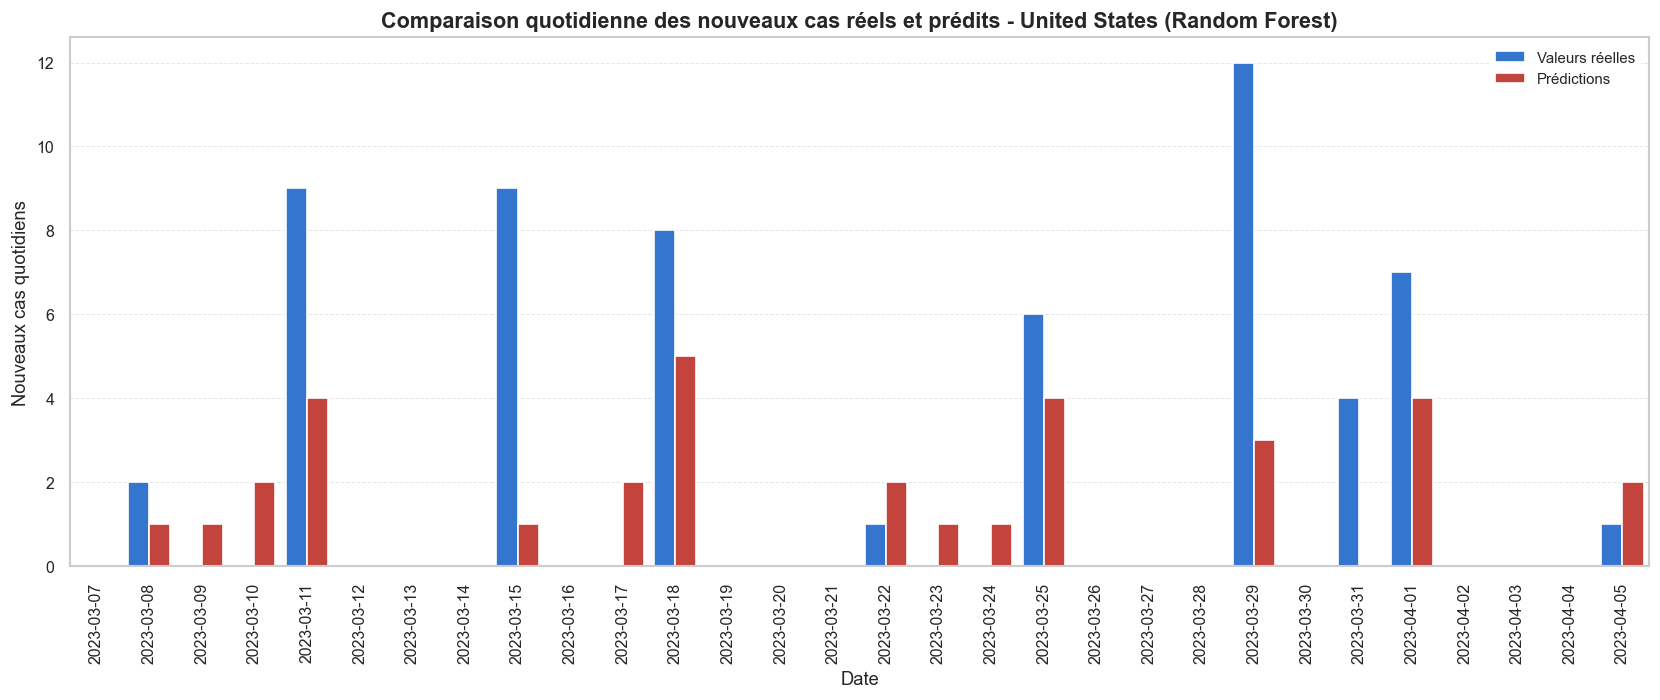

In [45]:
results_country = test[["date"]].copy()
results_country["Valeurs réelles"] = y_test.values
results_country["Prédictions"] = best_y_pred

results_plot = results_country.sort_values("date").head(30)

results_long = results_plot.melt(
    id_vars=["date"],
    value_vars=["Valeurs réelles", "Prédictions"],
    var_name="type",
    value_name="daily_new_cases"
)

plt.figure(figsize=(14, 6))

sns.barplot(
    data=results_long,
    x="date",
    y="daily_new_cases",
    hue="type"
)

plt.title(
    f"Comparaison quotidienne des nouveaux cas réels et prédits - {selected_country} ({best_model_name})"
)
plt.xlabel("Date")
plt.ylabel("Nouveaux cas quotidiens")
plt.xticks(rotation=90)
plt.legend(title="")
plt.tight_layout()
plt.show()

Le graphique montre que le modèle parvient à produire des prédictions dans le même ordre de grandeur que les valeurs réelles. Cependant, certains pics restent sous-estimés. Ce comportement est attendu avec des données épidémiologiques quotidiennes, car les pics peuvent dépendre de facteurs externes absents du dataset, comme les retards de déclaration, les changements de politique de dépistage ou les variations de surveillance sanitaire.

Le modèle doit donc être interprété comme une première approche exploratoire de prédiction, et non comme un outil de prévision opérationnelle.